In [1]:
import os
if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    
import torch    
import numpy as np

import xarray as xr
import shapely

import tqdm as tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')

figure_path = 'figures/'
os.makedirs(figure_path, exist_ok=True)

from helpers.transparent_colormaps import red_cmap, blue_cmap

In [2]:
from helpers.helper_functions import (
    SurfaceField_Distribution,
    convex_hull2D_prior_dist_constructor,
    concave_hull2D_prior_dist_constructor
)

from helpers.geographic_setup import (
    topo_data, nodes_full, nodes_shoulder, das_full, grid_coords,
)

A float can precisely represent any integer between -16777215 and +16777215, inclusive.

This means saving the index as a float is not problematic, as long as the index is within the range of -16777215 and +16777215.

# Model Prior

In [3]:
file_name_m_prior = 'data/priors/surface_displacement_prior.pt'

model_prior_sd = SurfaceField_Distribution(
    distibution=torch.load(file_name_m_prior, weights_only=False).forward(),
    topo_data=topo_data,
    depth=300,
)

In [4]:
model_prior_h = convex_hull2D_prior_dist_constructor(
    np.array(nodes_full[['easting', 'northing']].values.tolist()+[[500, 1800], [2000, 1800]]),
    topo_data,
    depth=300,
    buffer=150,
    base_dist='sobol'
)

In [5]:
concave_hull2D_prior = concave_hull2D_prior_dist_constructor(
    nodes_full[['easting', 'northing']].values,
    topo_data,
    buffer=20,
    depth=0,
    ratio=0.05,
    base_dist='sobol'
)

In [6]:
prior_sd = model_prior_sd.log_prob(
    grid_coords.squeeze(), fast_eval=False).exp().detach().numpy().reshape(topo_data.shape)

prior_h = model_prior_h.log_prob(
    grid_coords.squeeze(),
    fast_eval=False).exp().detach().numpy().reshape(topo_data.shape)

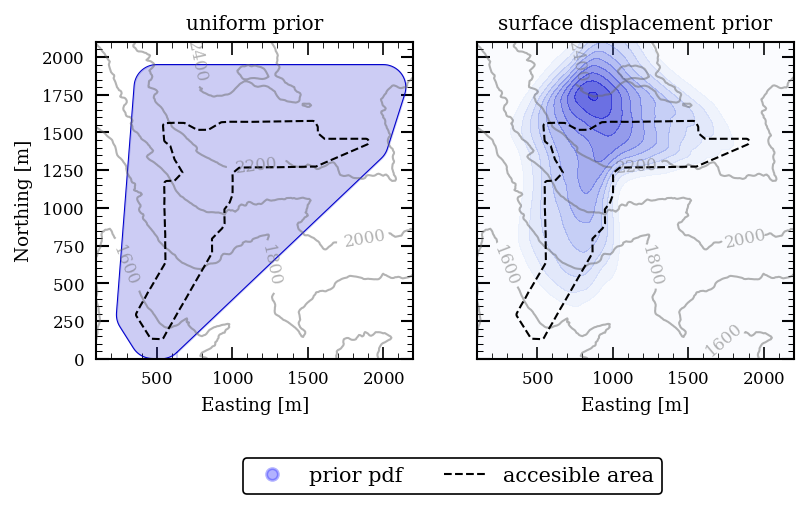

In [7]:
fig, ax_list = plt.subplots(
    1, 2, figsize=(6, 3), sharex=True, sharey=True)


ax = ax_list[0]

ax.set_ylabel('Northing [m]')
ax.set_title('uniform prior')
ax.fill_between(
    *np.array(model_prior_h.shapley_poly.exterior.coords.xy),
    color=(0.0, 0.0, 0.8), linewidth=None, zorder=2, alpha=0.2)    
ax.plot(
    *np.array(model_prior_h.shapley_poly.exterior.coords.xy),
    color=(0.0, 0.0, 0.8), linewidth=0.5, linestyle='-', zorder=2, alpha=1.0)


ax = ax_list[1]

ax.set_title('surface displacement prior')
ax.contourf(
    topo_data.easting, topo_data.northing, prior_sd.T, cmap=blue_cmap, levels=10, zorder=2)

ax.plot([], [], color='b', linestyle='', marker='o', label='prior pdf', alpha=0.3)

for ax in ax_list:

    topo_data_clipped = topo_data.sel(
        easting=slice(100, 2200),
        northing=slice(0, 2100)
    )

    contour = ax.contour(
        topo_data_clipped.easting, topo_data_clipped.northing, topo_data_clipped.values.T, 
        colors='dimgray', alpha=0.5,
        levels=[1600, 1800, 2000, 2200, 2400, 2600, 2800],
        linewidths=1.0)
    ax.clabel(contour, inline=True, fontsize=8, fmt='%1.0f')
        
    # ax.pcolormesh(
    # topo_data.easting, topo_data.northing, topo_data.values.T, rasterized=True,
    # cmap='Greys', zorder=-20, alpha=0.8)

    
    # ax.pc = ax.contour(
    #     topo_data.easting, topo_data.northing, topo_data.values.T, 
    #     colors='k', zorder=-10,
    #     levels=np.arange(0, 3000, 100),
    #     linewidths=0.5, alpha=0.5)
    
    # ax.cl = ax.clabel(
    #     ax.pc,
    #     levels=np.arange(0, 3000, 200),
    #     inline=True, fontsize=6, fmt='%1.0f', colors='k', use_clabeltext=True)
    
    ax.plot(
        *np.array(concave_hull2D_prior.shapley_poly.exterior.coords.xy),
        color='k', linewidth=1.0, linestyle='--', zorder=2, alpha=1.0, 
        label='accesible area')
    
    ax.set_aspect('equal')
    ax.set_xlabel('Easting [m]')
    
    ax.set_xlim(100, 2200)
    ax.set_ylim(0, 2100)
    
# empty plot for contour label
ax.legend(
    loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='black',
    bbox_to_anchor=(0.8, -0.25),
    bbox_transform=fig.transFigure,
    ncol=2)
    
fig.savefig(figure_path+'prior_comparison.png', dpi=300)
fig.savefig(figure_path+'prior_comparison.pdf', dpi=300)

plt.show()

# Precompute Prior Samples

In [8]:
# Precompute prior samples
num_samples = int(1e5)
torch.manual_seed(0)
prior_samples_full_disp = model_prior_sd.sample((num_samples,))
prior_samples_full_uniform = model_prior_h.sample((num_samples,))

# Add index column to samples
indices = torch.arange(num_samples).unsqueeze(1)
prior_samples_full_disp = torch.cat([prior_samples_full_disp, indices], dim=1)
prior_samples_full_uniform = torch.cat([prior_samples_full_uniform, indices], dim=1)

torch.save(prior_samples_full_disp, 'data/priors/prior_samples_full_disp.pt')
torch.save(prior_samples_full_uniform, 'data/priors/prior_samples_full_uniform.pt')

# Shoulder

In [9]:
model_prior_h_shoulder = convex_hull2D_prior_dist_constructor(
    nodes_shoulder[['easting', 'northing']].values,
    topo_data,
    depth=10, buffer=20, base_dist='sobol'
)

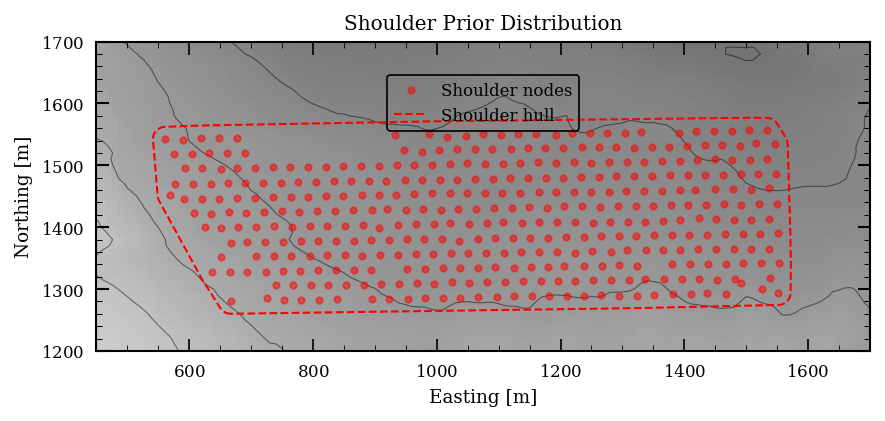

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot topography
ax.pcolormesh(
    topo_data.easting, topo_data.northing, topo_data.values.T,
    rasterized=True, cmap='Greys', zorder=-20, alpha=0.8
)

# Add contour lines
pc = ax.contour(
    topo_data.easting, topo_data.northing, topo_data.values.T,
    colors='k', zorder=-10, levels=np.arange(0, 3000, 100),
    linewidths=0.5, alpha=0.5
)

# Add contour labels
cl = ax.clabel(
    pc, levels=np.arange(0, 3000, 200),
    inline=True, fontsize=6, fmt='%1.0f', colors='k', use_clabeltext=True
)

# Plot shoulder nodes
ax.scatter(nodes_shoulder['easting'], nodes_shoulder['northing'], 
          c='r', s=10, alpha=0.5, label='Shoulder nodes')

# Plot the hull boundary
ax.plot(
    *np.array(model_prior_h_shoulder.shapley_poly.exterior.coords.xy),
    color='r', linewidth=1.0, linestyle='--', zorder=2, alpha=1.0,
    label='Shoulder hull'
)

ax.set_xlim(450, 1700)
ax.set_ylim(1200, 1700)

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('Shoulder Prior Distribution')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
torch.manual_seed(0)
prior_samples_shoulder_uniform = model_prior_h_shoulder.sample((num_samples,))

indices = torch.arange(num_samples).unsqueeze(1)
prior_samples_shoulder_uniform = torch.cat([prior_samples_shoulder_uniform, indices], dim=1)

torch.save(prior_samples_shoulder_uniform, 'data/priors/prior_samples_shoulder_uniform.pt')

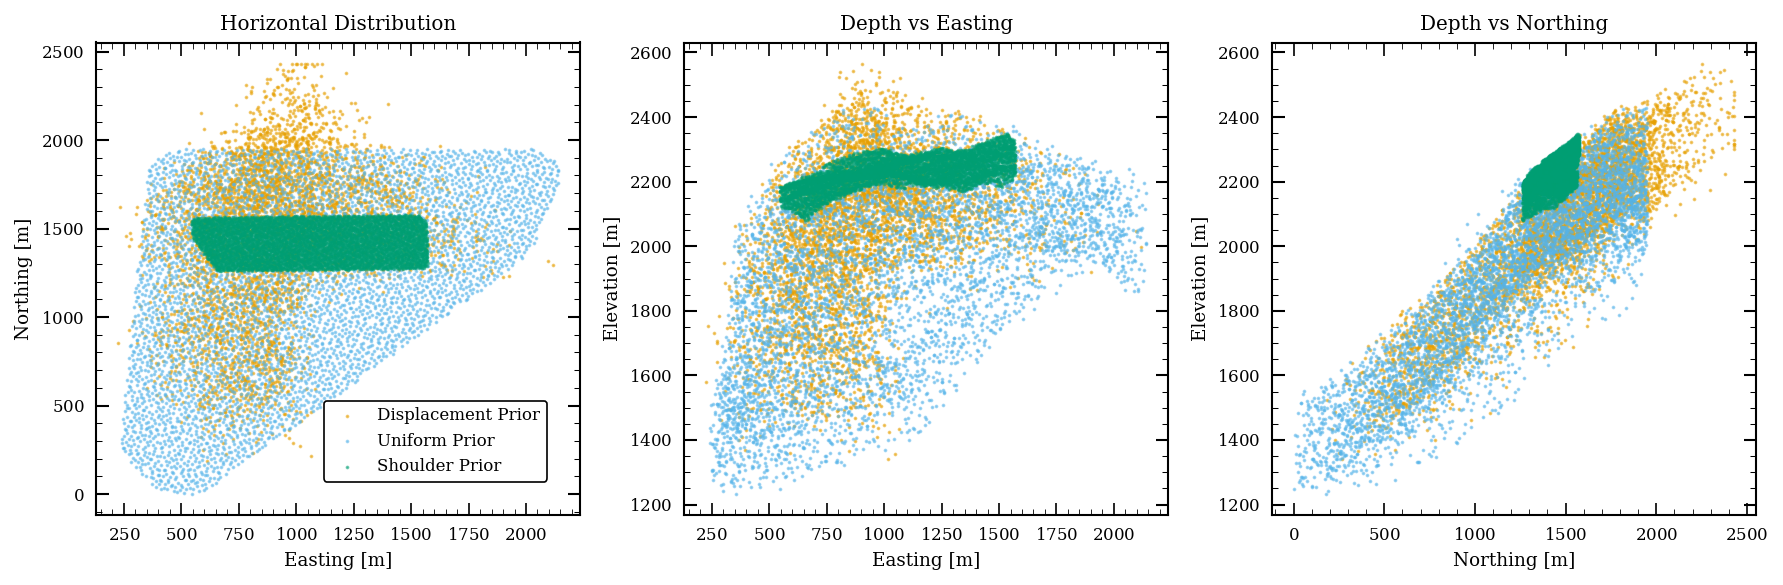

In [12]:
fig, ax_list = plt.subplots(1, 3, figsize=(12, 4))

# Plot horizontal distribution (XY)
ax = ax_list[0]
ax.scatter(prior_samples_full_disp[:5000, 0], prior_samples_full_disp[:5000, 1], 
          s=1, alpha=0.5, label='Displacement Prior')
ax.scatter(prior_samples_full_uniform[:5000, 0], prior_samples_full_uniform[:5000, 1], 
          s=1, alpha=0.5, label='Uniform Prior')
ax.scatter(prior_samples_shoulder_uniform[:5000, 0], prior_samples_shoulder_uniform[:5000, 1], 
          s=1, alpha=0.5, label='Shoulder Prior')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('Horizontal Distribution')
ax.legend()

# Plot depth vs easting
ax = ax_list[1]
ax.scatter(prior_samples_full_disp[:5000, 0], prior_samples_full_disp[:5000, 2], 
          s=1, alpha=0.5, label='Displacement Prior')
ax.scatter(prior_samples_full_uniform[:5000, 0], prior_samples_full_uniform[:5000, 2], 
          s=1, alpha=0.5, label='Uniform Prior')
ax.scatter(prior_samples_shoulder_uniform[:5000, 0], prior_samples_shoulder_uniform[:5000, 2], 
          s=1, alpha=0.5, label='Shoulder Prior')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Elevation [m]')
ax.set_title('Depth vs Easting')

# Plot depth vs northing
ax = ax_list[2]
ax.scatter(prior_samples_full_disp[:5000, 1], prior_samples_full_disp[:5000, 2], 
          s=1, alpha=0.5, label='Displacement Prior')
ax.scatter(prior_samples_full_uniform[:5000, 1], prior_samples_full_uniform[:5000, 2], 
          s=1, alpha=0.5, label='Uniform Prior')
ax.scatter(prior_samples_shoulder_uniform[:5000, 1], prior_samples_shoulder_uniform[:5000, 2], 
          s=1, alpha=0.5, label='Shoulder Prior')
ax.set_xlabel('Northing [m]')
ax.set_ylabel('Elevation [m]')
ax.set_title('Depth vs Northing')

plt.tight_layout()
plt.show()